# ERA5 versus ERA5-Land: Spain–Morocco transect

This notebook compares surface pressure, terrain elevation, and hydrostatic altitude estimates along a north–south transect across the Strait of Gibraltar.

The input files should be small NetCDF extracts downloaded for the same UTC time and covering approximately longitude `-5.8` to `-5.0` and latitude `35.5` to `36.4`. Each file must contain surface pressure, 2 m temperature, and either geopotential or surface elevation.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Resolve paths whether Jupyter was launched from the repository root or scripts/.
project_dir = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
era5_file = project_dir / "data/era5_gibraltar/era5_gibraltar.nc"
era5_land_file = project_dir / "data/era5_gibraltar/era5_land_gibraltar.nc"

# Use one common UTC time present in both files
time = "2020-07-15T12:00:00"
logger_pressure_hpa = 950.0

# Fixed longitude crossing the Strait; adjust to the downloaded grid
transect_longitude = -5.5
# Keep the transect within the common ERA5 and ERA5-Land latitude range.
transect_latitude = np.linspace(35.5, 36.25, 150)

R_d = 287.05
g = 9.80665
L = 0.0065

In [ ]:
era5 = xr.open_dataset(era5_file)
era5_land = xr.open_dataset(era5_land_file)

<xarray.Dataset> Size: 288B
Dimensions:    (time: 1, latitude: 4, longitude: 4)
Coordinates:
    number     int64 8B ...
  * time       (time) datetime64[ns] 8B 2020-07-15T12:00:00
  * latitude   (latitude) float64 32B 36.25 36.0 35.75 35.5
  * longitude  (longitude) float64 32B -5.75 -5.5 -5.25 -5.0
    expver     <U4 16B ...
Data variables:
    t2m        (time, latitude, longitude) float32 64B ...
    sp         (time, latitude, longitude) float32 64B ...
    z          (time, latitude, longitude) float32 64B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-05T19:26 GRIB to CDM+CF via cfgrib-0.9.1...
<xarray.Dataset> Size: 2kB
Dimensions:    (time: 1, latitude: 10, longitude: 9)
Coordinates:
    number     int64 8B ...
  *

In [3]:
# Select the common time and the nearest longitude for each dataset.
# ERA5 geopotential is m2 s-2 and is converted to geopotential height.
# If the file contains altitude/orography in metres, use it directly.

era5_at_time = era5.sel(time=np.datetime64(time), method="nearest")
era5_land_at_time = era5_land.sel(time=np.datetime64(time), method="nearest")

era5_lat_name = "latitude" if "latitude" in era5.coords else "lat"
era5_lon_name = "longitude" if "longitude" in era5.coords else "lon"
land_lat_name = "latitude" if "latitude" in era5_land.coords else "lat"
land_lon_name = "longitude" if "longitude" in era5_land.coords else "lon"

era5_at_time = era5_at_time.sel({era5_lon_name: transect_longitude}, method="nearest")
era5_land_at_time = era5_land_at_time.sel({land_lon_name: transect_longitude}, method="nearest")

In [4]:
# ERA5 variable names
era5_surface_pressure = era5_at_time["sp"] if "sp" in era5_at_time else era5_at_time["surface_pressure"]
era5_temperature = era5_at_time["t2m"] if "t2m" in era5_at_time else era5_at_time["2m_temperature"]
era5_elevation_name = "z" if "z" in era5_at_time else ("geopotential" if "geopotential" in era5_at_time else "altitude")
era5_elevation = era5_at_time[era5_elevation_name]

# ERA5-Land variable names
land_surface_pressure = era5_land_at_time["sp"] if "sp" in era5_land_at_time else era5_land_at_time["surface_pressure"]
land_temperature = era5_land_at_time["t2m"] if "t2m" in era5_land_at_time else era5_land_at_time["2m_temperature"]
land_elevation_name = "z" if "z" in era5_land_at_time else ("geopotential" if "geopotential" in era5_land_at_time else "altitude")
land_elevation = era5_land_at_time[land_elevation_name]

# Interpolate each field along the fixed-longitude transect.
era5_surface_pressure = era5_surface_pressure.interp({era5_lat_name: transect_latitude}) / 100
era5_temperature = era5_temperature.interp({era5_lat_name: transect_latitude})
era5_elevation = era5_elevation.interp({era5_lat_name: transect_latitude})
land_surface_pressure = land_surface_pressure.interp({land_lat_name: transect_latitude}) / 100
land_temperature = land_temperature.interp({land_lat_name: transect_latitude})
land_elevation = land_elevation.interp({land_lat_name: transect_latitude})
if era5_elevation_name in ("z", "geopotential"):
    era5_elevation = era5_elevation / g
if land_elevation_name in ("z", "geopotential"):
    land_elevation = land_elevation / g

# Hydrostatic altitude estimate for the same logger pressure.
era5_altitude = era5_elevation + era5_temperature / L * (((logger_pressure_hpa / era5_surface_pressure) ** (-R_d * L / g)) - 1)
land_altitude = land_elevation + land_temperature / L * (((logger_pressure_hpa / land_surface_pressure) ** (-R_d * L / g)) - 1)

comparison = pd.DataFrame({
    "latitude": transect_latitude,
    "era5_elevation_m": era5_elevation.values,
    "era5_land_elevation_m": land_elevation.values,
    "era5_pressure_hpa": era5_surface_pressure.values,
    "era5_land_pressure_hpa": land_surface_pressure.values,
    "era5_altitude_m": era5_altitude.values,
    "era5_land_altitude_m": land_altitude.values,
})
comparison["elevation_difference_m"] = comparison.era5_land_elevation_m - comparison.era5_elevation_m
comparison["pressure_difference_hpa"] = comparison.era5_land_pressure_hpa - comparison.era5_pressure_hpa
comparison["altitude_difference_m"] = comparison.era5_land_altitude_m - comparison.era5_altitude_m
comparison["expected_pressure_difference_hpa"] = -(comparison.era5_pressure_hpa * g * comparison.elevation_difference_m / (R_d * ((era5_temperature.values + land_temperature.values) / 2)))
comparison["era5_land_available"] = comparison.era5_land_pressure_hpa.notna()

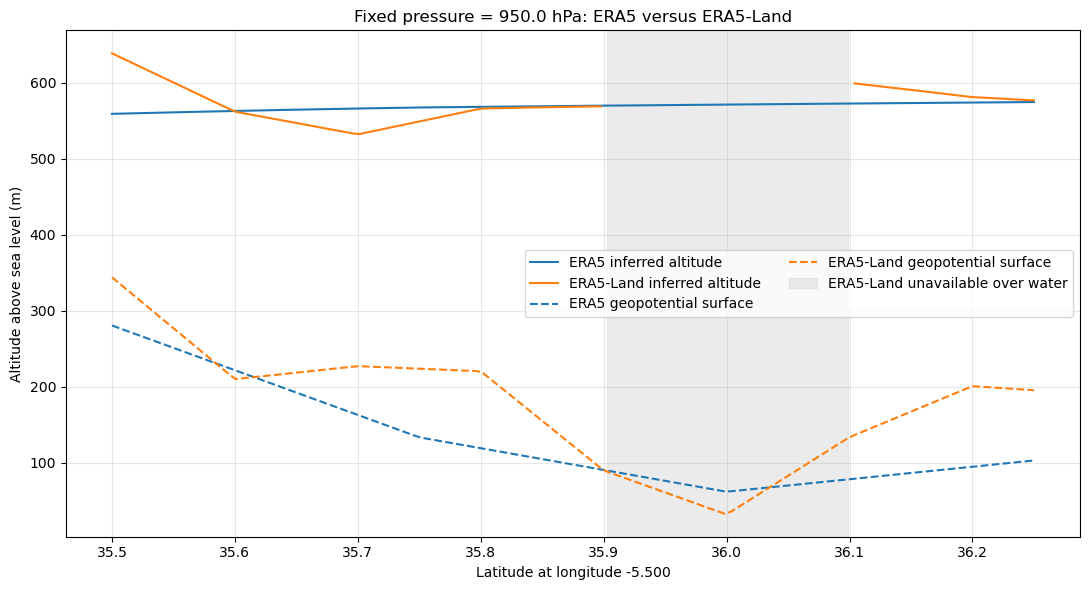

In [5]:
# Main plot: fixed pressure converted to altitude using both datasets.
# The surface profiles are the geopotential-derived ground levels.
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(comparison.latitude, comparison.era5_altitude_m, color="tab:blue", label="ERA5 inferred altitude")
ax.plot(comparison.latitude, comparison.era5_land_altitude_m, color="tab:orange", label="ERA5-Land inferred altitude")
ax.plot(comparison.latitude, comparison.era5_elevation_m, color="tab:blue", linestyle="--", label="ERA5 geopotential surface")
ax.plot(comparison.latitude, comparison.era5_land_elevation_m, color="tab:orange", linestyle="--", label="ERA5-Land geopotential surface")
water = ~comparison.era5_land_available
if water.any():
    ymin, ymax = ax.get_ylim()
    ax.fill_between(comparison.latitude, ymin, ymax, where=water, color="0.85", alpha=0.5, label="ERA5-Land unavailable over water")
    ax.set_ylim(ymin, ymax)
ax.set_xlabel("Latitude at longitude {:.3f}".format(float(era5_at_time[era5_lon_name])))
ax.set_ylabel("Altitude above sea level (m)")
ax.set_title("Fixed pressure = {:.1f} hPa: ERA5 versus ERA5-Land".format(logger_pressure_hpa))
ax.legend(ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [6]:
# Print the most relevant discrepancies and save a compact CSV for reporting.
display(comparison.iloc[::10].round(3))
print("Maximum absolute inferred-altitude difference: {:.2f} m".format(comparison.altitude_difference_m.abs().max()))
print("Maximum absolute elevation difference: {:.2f} m".format(comparison.elevation_difference_m.abs().max()))
print("Maximum absolute pressure residual: {:.2f} hPa".format((comparison.pressure_difference_hpa - comparison.expected_pressure_difference_hpa).abs().max()))
print("ERA5-Land unavailable at {} of {} transect points (water)".format((~comparison.era5_land_available).sum(), len(comparison)))
comparison.to_csv("era5_land_gibraltar_transect_comparison.csv", index=False)

,latitude,era5_elevation_m,era5_land_elevation_m,era5_pressure_hpa,era5_land_pressure_hpa,era5_altitude_m,era5_land_altitude_m,elevation_difference_m,pressure_difference_hpa,altitude_difference_m,expected_pressure_difference_hpa,era5_land_available
0,35.500,280.610,344.006,980.519,982.292,559.068,638.647,63.396,1.773,79.579,-7.077,True
10,35.550,250.982,276.567,984.067,985.539,561.057,600.102,25.585,1.471,39.045,-2.869,True
20,35.601,221.354,210.141,987.615,988.707,562.894,561.743,-11.213,1.092,-1.150,1.263,True
30,35.651,191.726,218.752,991.162,986.105,564.577,546.698,27.026,-5.058,-17.879,-3.059,True
40,35.701,162.098,227.042,994.710,983.634,566.110,532.514,64.944,-11.076,-33.596,-7.384,True
50,35.752,132.977,223.639,998.198,985.965,567.477,549.616,90.662,-12.233,-17.861,-10.355,True
60,35.802,118.566,217.745,999.954,988.507,568.316,566.034,99.179,-11.446,-2.282,-11.356,True
70,35.852,104.155,152.058,1001.709,996.138,569.117,567.749,47.903,-5.571,-1.367,-5.498,True
80,35.903,89.744,88.322,1003.465,NaN,569.878,NaN,-1.422,NaN,NaN,NaN,False
90,35.953,75.333,59.191,1005.221,NaN,570.600,NaN,-16.142,NaN,NaN,NaN,False


Maximum absolute inferred-altitude difference: 79.58 m
Maximum absolute elevation difference: 105.87 m
Maximum absolute pressure residual: 8.85 hPa
ERA5-Land unavailable at 40 of 150 transect points (water)
